In [5]:
import os
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from rapidfuzz import fuzz, process
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import SparsePCA
from sklearn.model_selection import train_test_split

from scholarlm.utils import get_filenames_in_directory, get_foldernames_in_directory, correct_image_orientation

### Load Data

In [2]:
main_directory = os.getenv("POND_PATH")
data_directory = os.getenv("POND_DATA_PATH")
pdf_directory = os.getenv("POND_PDF_PATH")
text_directory = os.getenv("POND_TEXT_PATH")
image_directory = os.getenv("POND_IMAGE_PATH")

In [57]:
finished_papers = [0,1,2,3,4,6,8,9]
data = []
for i in finished_papers:
    filename = f"../data/pond_results_10_papers_v1_{i}.json"
    with open(filename, "r") as f:
        file_data = json.load(f)
        for entry in file_data:
            entry['paper_id'] = i

        data.extend(file_data)

outfile = "../data/pond_results_10_papers_v1.json"
with open(outfile, "w") as f:
    json.dump(data, f, indent=4)

In [30]:
# Directory
with open(os.path.join(main_directory, "directory.json"), "r") as f:
    paper_info = json.load(f)
registered_titles = [entry['title'] for entry in paper_info.values()]
registered_titles.sort()
registered_titles = [registered_titles[i] for i in finished_papers]

# Original dataset
pond_data = pd.read_csv(os.path.join(data_directory, "pond_data.csv"), encoding_errors='ignore')
pond_data = pond_data.loc[pond_data.title.isin(registered_titles)]
pond_df = pond_data.loc[:,['author', 'title', 'pondname', 'location', 'author_term',
            'max_depth_m', 'mean_surfacearea_m2', 'macrophytes_percentcover', 'ph', 'tn_ugpl', 'tp_ugpl', 'chla_ugpl']]
pond_df.columns = ['author', 'title', 'name', 'location', 'ecosystem',
            'max_depth', 'surface_area', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla']

# Split the dataframe's rows so that each measurement is in its own row
pond_df = pond_df.melt(id_vars=['author', 'title', 'name', 'location', 'ecosystem'], 
                       value_vars=['max_depth', 'surface_area', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla'],
                       var_name='measurement', value_name='value')
pond_df = pond_df.dropna(subset=['value'])
pond_df = pond_df.reset_index(drop=True)
n_entries = pond_df.shape[0]

In [31]:
def process(
    result_df,
    conversion_table
):
    result_df = result_df.copy()

    # Drop rows without any measurements
    result_df = result_df.dropna(subset=['value'])
    result_df = result_df.reset_index(drop=True)

    # Convert units
    for row_idx, row in result_df.iterrows():
        measurement_type = row['measurement']
        val = row['value']
        unit = row['units']
        if conversion_table.get(measurement_type) is not None:
            if conversion_table[measurement_type].get(unit) is not None:
                conversion_factor = conversion_table[measurement_type][unit]
                result_df.at[row_idx, 'value'] = val * conversion_factor
            else:
                result_df.at[row_idx, 'value'] = np.nan # Units not recognized

    result_df = result_df.dropna(subset=['value'])
    result_df = result_df.reset_index(drop=True)

    # Drop all unit columns
    result_df = result_df.drop(columns=["units"])

    # Drop exact duplicates
    result_df = result_df.drop_duplicates()

    # Reset index
    result_df = result_df.reset_index(drop=True)

    return result_df


conversion_table = {
    'depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 1e6, "ha": 1e4, "mi^2": 2.59e6, "m^2": 1},
    'vegetation_cover': {"percent": 0.01, "fraction": 1},
    'tn': {"mg/L": 1000, "µg/L": 1, "μmol/L": 14.01, "ppm": 1000, "ppb": 1},
    'tp': {"mg/L": 1000, "µg/L": 1, "μmol/L": 30.97, "ppm": 1000, "ppb": 1},
    'chl': {"mg/L": 1000, "µg/L": 1}
}

In [47]:
with open("../data/pond_results_10_papers_v1.json", "r") as f:
    result_dict = json.load(f)

scores = ['context_scores', 'parametric_scores', 'copying_scores', 'linear_probes']
result_df = [{k:v for k,v in entry.items() if k not in scores} for entry in result_dict]
result_df = pd.DataFrame(result_df)

In [ ]:
#result_df = pd.read_csv('../data/pond_results_10_papers_base.csv')

In [ ]:
result_df = result_df.loc[result_df.title.isin(registered_titles)]
result_df = result_df.reset_index(drop=True)

ignore_measurements = ['latitude', 'longitude'] # Ignoring these for now because they are not in the original dataset

result_df = result_df.loc[~result_df.measurement.isin(ignore_measurements)]
result_df['value'] = result_df['value'].str.replace(',', '')  # Remove commas from numbers
result_df['value'] = pd.to_numeric(result_df['value'], errors='coerce')
result_df = process(result_df, conversion_table)
result_df.sort_values(by=["title"], inplace=True)
result_df = result_df.reset_index(drop=True)

In [60]:
with open("../data/pond_results_10_papers_v1_validated.json", "r") as f:
    result_dict_validated = json.load(f)
scores = ['context_scores', 'parametric_scores', 'copying_scores', 'linear_probes']
result_df_validated = [{k:v for k,v in entry.items() if k not in scores} for entry in result_dict_validated]
result_df_validated = pd.DataFrame(result_df_validated)

#result_df_validated = pd.read_csv('../data/pond_results4_validated.csv')
result_df_validated = result_df_validated.loc[~result_df_validated.measurement.isin(ignore_measurements)]
result_df_validated['value'] = result_df_validated['value'].str.replace(',', '')  # Remove commas from numbers
result_df_validated['value'] = pd.to_numeric(result_df_validated['value'], errors='coerce')
result_df_validated = process(result_df_validated, conversion_table)

In [39]:
pond_df.loc[pond_df.title == registered_titles[7], :].sort_values(by='measurement')

,author,title,name,location,ecosystem,measurement,value
154,hsu,biodiversity of constructed wetlands for waste...,dn5,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,chla,149.9
142,hsu,biodiversity of constructed wetlands for waste...,hs2-1,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,chla,30.8
143,hsu,biodiversity of constructed wetlands for waste...,hs2-2,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,chla,26.3
144,hsu,biodiversity of constructed wetlands for waste...,hs2-3,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,chla,28.0
145,hsu,biodiversity of constructed wetlands for waste...,hs2-4,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,chla,46.0
...,...,...,...,...,...,...,...
67,hsu,biodiversity of constructed wetlands for waste...,hs2-2,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,vegetation_cover,65.0
66,hsu,biodiversity of constructed wetlands for waste...,hs2-1,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,vegetation_cover,20.0
78,hsu,biodiversity of constructed wetlands for waste...,dn5,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,vegetation_cover,20.0
71,hsu,biodiversity of constructed wetlands for waste...,dn1,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,vegetation_cover,5.0


In [40]:
result_df.loc[result_df.title == registered_titles[7], :].iloc[:, :12].sort_values(by='measurement')

,title,author,year,location,paper_id,date,name,context,ecosystem,chunk_id,measurement,value
128,biodiversity of constructed wetlands for waste...,hsu,2011,None,7,None,Ecological pond,<table>\n <tr>\n <th>Treatment cell</th>\n...,pond,23,chla,91.700
122,biodiversity of constructed wetlands for waste...,hsu,2011,None,7,None,Hsin-Hai II Constructed Wetland,<table>\n <tr>\n <th>Treatment cell</th>\n...,wetland,23,chla,30.800
121,biodiversity of constructed wetlands for waste...,hsu,2011,None,7,None,Heavily vegetated pond I-C,<table>\n <tr>\n <th>Treatment cell</th>\n...,pond,23,chla,136.100
125,biodiversity of constructed wetlands for waste...,hsu,2011,None,7,None,Open-water pond,<table>\n <tr>\n <th>Treatment cell</th>\n...,pond,23,chla,43.200
126,biodiversity of constructed wetlands for waste...,hsu,2011,None,7,None,Heavily vegetated pond I,<table>\n <tr>\n <th>Treatment cell</th>\n...,pond,23,chla,46.000
...,...,...,...,...,...,...,...,...,...,...,...,...
155,biodiversity of constructed wetlands for waste...,hsu,2011,None,7,None,HS2-1,"<table>\n <tr>\n <th rowspan=""2"">Aquatic m...",pond,36,vegetation_cover,0.075
154,biodiversity of constructed wetlands for waste...,hsu,2011,None,7,None,DN1,"<table>\n <tr>\n <th rowspan=""2"">Aquatic m...",pond,36,vegetation_cover,0.014
153,biodiversity of constructed wetlands for waste...,hsu,2011,None,7,1997,hemi-marshes,Changes in macrophyte composition and cover ar...,wetland,74,vegetation_cover,0.500
151,biodiversity of constructed wetlands for waste...,hsu,2011,None,7,None,HS2-5,"<table>\n <tr>\n <th rowspan=""2"">Aquatic m...",pond,36,vegetation_cover,0.043


In [42]:
print(result_df.loc[result_df.title == registered_titles[7], :].iloc[:, :11].sort_values(by='measurement').iloc[0,:].context)

<table>
  <tr>
    <th>Treatment cell</th>
    <th>Cell code</th>
    <th>n</th>
    <th>WT (°C)</th>
    <th>Conductivity (μS cm<sup>-1</sup>)</th>
    <th>DO (ppm)</th>
    <th>pH</th>
    <th>SS (mg L<sup>-1</sup>)</th>
    <th>BOD (mg L<sup>-1</sup>)</th>
    <th>COD (mg L<sup>-1</sup>)</th>
    <th>NO<sub>x</sub>N (mg L<sup>-1</sup>)</th>
    <th>TN (mg L<sup>-1</sup>)</th>
    <th>TP (mg L<sup>-1</sup>)</th>
    <th>Chl-a (mg m<sup>-3</sup>)</th>
  </tr>
  <tr>
    <th colspan="15">Hsin-Hai II Constructed Wetland (HS2)</th>
  </tr>
  <tr>
    <td>Depositional pond</td>
    <td>HS2-1</td>
    <td>7</td>
    <td>26.1</td>
    <td>495.4</td>
    <td>1.30</td>
    <td>7.04</td>
    <td>27.5</td>
    <td>27.12</td>
    <td>79.51</td>
    <td>0.135</td>
    <td>19.38</td>
    <td>1.30</td>
    <td>30.8</td>
  </tr>
  <tr>
    <td>Heavily vegetated pond I</td>
    <td>HS2-2</td>
    <td>8</td>
    <td>25.7</td>
    <td>436.6</td>
    <td>2.09</td>
    <td>7.20</td>
    <td>7.4</td>
    

In [ ]:
result_df.loc[result_df.title == registered_titles[7], :].iloc[:, :11]

In [ ]:
print(result_df.loc[result_df.title == registered_titles[7], :].iloc[0,:].context)

In [ ]:
filepath = os.path.join(text_directory, "biodiversity_of_constructed.json")
chunks = []
with open(filepath, 'r', encoding='utf-8') as file:
    doc_chunks = json.load(file)
    chunks.append(doc_chunks)

In [ ]:
print(chunks[0][23])

### LLM as Judge Baseline

In [71]:
status_dict = {
    'valid': 1,
    'hallucination': 0,
    'disorientation': 1,
    'deviation': 1,
}

bool_dict = {
    'true': 1,
    'false': 0,
}

y_judge = result_df_validated['judgement'].map(bool_dict)
y_valid = result_df_validated['validation_status'].map(status_dict)

accuracy = (y_judge == y_valid).mean()
print(f"LLM Judge Accuracy: {accuracy:.4f}")

LLM Judge Accuracy: 0.8571


### Manually validated model

In [ ]:
context_columns = []
context_columns_by_layer = [[] for _ in range(32)]
parametric_columns = []

for col in result_df_validated.columns:
    if col.startswith('context_'):
        context_columns.append(col)
        layer_num = int(col.split('_')[-1].split('h')[0][1:])
        context_columns_by_layer[layer_num].append(col)
    elif col.startswith('parametric_'):
        parametric_columns.append(col)

In [ ]:
pond_results_aggregate = result_df_validated.drop(columns = context_columns)
context_columns_aggregate = []
for layer_num in range(32):
    cols = context_columns_by_layer[layer_num]
    pond_results_aggregate[f'context_l{layer_num}'] = result_df_validated[cols].mean(axis=1)
    context_columns_aggregate.append(f'context_l{layer_num}')

In [ ]:
status_dict = {
    'valid': 1,
    'hallucination': 0,
    'disorientation': 0,
    'deviation': 1,
}

X = result_df_validated[context_columns + parametric_columns]
y = result_df_validated['validation_status'].map(status_dict)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Fitting regularization parameter for logistic regression
regularization_params = np.linspace(0.0, 0.001, 101)
scores = np.empty((len(regularization_params), 5))

for i, alpha in enumerate(regularization_params):
    model = LogisticRegression(C=1/(alpha + 1e-10), penalty = "l1", solver = "liblinear", max_iter=1000)
    cv_results = cross_validate(model, X, y, cv=5, scoring='accuracy')
    scores[i, :] = cv_results['test_score']

In [ ]:
np.mean(scores, axis=1)

In [ ]:
regularization_params[10]

In [ ]:
plt.plot(regularization_params, np.mean(scores, axis = 1))
plt.xlabel('Regularization Parameter (alpha)')
plt.ylabel('Reconstruction Error')

In [ ]:
regularization_params[np.argmax(np.mean(scores, axis=1))]

In [ ]:
# Fit logistic regression model
alpha = 9e-05
model = LogisticRegression(C = 1/(alpha + 1e-10), penalty = "l1", solver='liblinear', max_iter=1000, random_state = 342)
model.fit(X, y)
#train_accuracy = model.score(X_train, y_train)
#print(f"Logistic Regression Train Accuracy: {train_accuracy:.4f}")
#accuracy = model.score(X, y)
#print(f"Logistic Regression Test Accuracy: {accuracy:.4f}")

coefficients = model.coef_[0]
context_coefficients = coefficients[:-32].reshape(32, 32)
parametric_coefficients = coefficients[-32:]

In [ ]:
model.predict(X_test)

In [ ]:
y_test

In [ ]:
pond_df

In [ ]:
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(context_coefficients, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Context Score Coefficients')
fig.colorbar(pos, ax=ax)

In [ ]:
fig,ax = plt.subplots(figsize=(6,4), dpi = 100)
ax.bar(
    range(len(parametric_coefficients)), parametric_coefficients, alpha = 0.5
)
ax.set_ylabel('Parametric Score Coefficients')
ax.set_xlabel('Layers')

In [78]:
hallucination_indices = [i for i,entry in enumerate(result_dict_validated) if entry['validation_status'] == 'hallucination']

In [79]:
hallucination_indices

[26, 42]

In [100]:
result_dict_validated[26]

{'title': 'aquatic insect assemblages of man-made permanent ponds; buenos aires city; argentina',
 'author': 'fontanarrosa',
 'year': 2013,
 'context': '<table>\n  <tr>\n    <th></th>\n    <th>P1</th>\n    <th>P2</th>\n    <th>P3</th>\n    <th>P4</th>\n  </tr>\n  <tr>\n    <td>Area (\\( \\mathrm{m}^2 \\))</td>\n    <td>4,700</td>\n    <td>9,500</td>\n    <td>99,700</td>\n    <td>49,400</td>\n  </tr>\n  <tr>\n    <td>Max. depth (m)</td>\n    <td>\\( \\approx 1 \\)</td>\n    <td>\\( \\approx 1 \\)</td>\n    <td>\\( \\approx 5 \\)</td>\n    <td>\\( \\approx 1 \\)</td>\n  </tr>\n  <tr>\n    <td>Substrate</td>\n    <td>Natural</td>\n    <td>Natural</td>\n    <td>Natural</td>\n    <td>Natural</td>\n  </tr>\n  <tr>\n    <td>Shoreline</td>\n    <td>Natural</td>\n    <td>Concrete and granite (sloping)</td>\n    <td>Concrete and granite (sloping)</td>\n    <td>Concrete (vertical)</td>\n  </tr>\n  <tr>\n    <td>Aquatic vegetation</td>\n    <td>Poorly represent and frequently removed</td>\n    <td

In [108]:
idx1 = 25
datapoint1 = result_dict_validated[idx1]

idx2 = 26
datapoint2 = result_dict_validated[idx2]

(-0.05, 0.05)

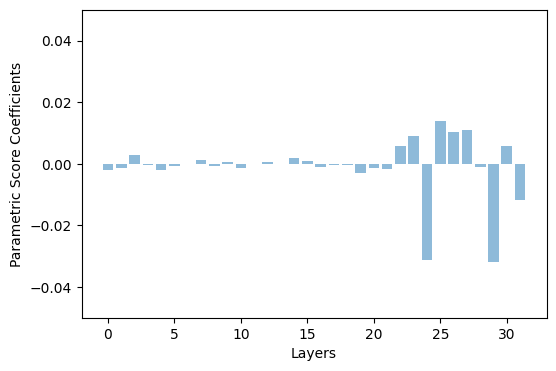

In [110]:
# parametric knowledge scores:
parametric_coefficients1 = datapoint1['parametric_scores']
parametric_coefficients1 = np.array([parametric_coefficients1.get(f'l{i}') for i in range(32)])

parametric_coefficients2 = datapoint2['parametric_scores']
parametric_coefficients2 = np.array([parametric_coefficients2.get(f'l{i}') for i in range(32)])

fig,ax = plt.subplots(figsize=(6,4), dpi = 100)
ax.bar(
    range(len(parametric_coefficients)), parametric_coefficients1 - parametric_coefficients2, alpha = 0.5
)
ax.set_ylabel('Parametric Score Coefficients')
ax.set_xlabel('Layers')
ax.set_ylim(-0.05, 0.05)

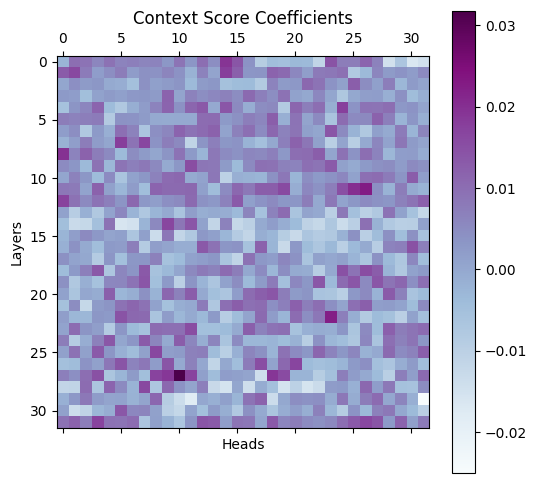

In [111]:
context_coefficients = np.zeros((32,32))
for layer in range(32):
    for head in range(32):
        context_coefficients[layer, head] = datapoint1['context_scores'].get(f'l{layer}h{head}', 0.0) - datapoint2['context_scores'].get(f'l{layer}h{head}', 0.0)
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(context_coefficients, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Context Score Coefficients')
fig.colorbar(pos, ax=ax)




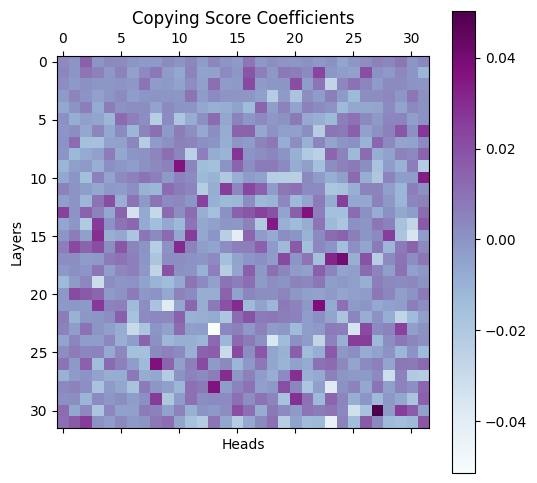

In [112]:
copying_coefficients = np.zeros((32,32))
for layer in range(32):
    for head in range(32):
        copying_coefficients[layer, head] = context_coefficients[layer, head] = datapoint1['copying_scores'].get(f'l{layer}h{head}', 0.0) - datapoint2['copying_scores'].get(f'l{layer}h{head}', 0.0)
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(copying_coefficients, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Copying Score Coefficients')
fig.colorbar(pos, ax=ax)

### Matching to dataset

In [43]:
def match_datapoints(ground_truth, extracted):
    edges = []
    edge_weights = []
    for i, row_gt in ground_truth.iterrows():
        for j, row_ex in extracted.iterrows():
            if (
                row_gt['title'] == row_ex['title'] and 
                row_gt['measurement'] == row_ex['measurement'] and 
                np.isclose(row_gt['value'], row_ex['value'], atol=1e-3)
            ):
                name_similarity = fuzz.ratio(row_gt['name'], row_ex['name']) / 100.0
                location_similarity = fuzz.ratio(row_gt['location'], row_ex['location']) / 100.0
                ecosystem_similarity = fuzz.ratio(row_gt['ecosystem'], row_ex['ecosystem']) / 100.0
                weight = (name_similarity + location_similarity + ecosystem_similarity) / 3.0
                edges.append((i, j))
                edge_weights.append(weight)

    print(f"Total edges found: {len(edges)}")
    # Create a bipartite graph and find maximum weight matching
    G = nx.Graph()
    G.add_edges_from([(f"gt_{i}", f"ex_{j}", {'weight': w}) for (i, j), w in zip(edges, edge_weights)])
    matching = nx.algorithms.matching.max_weight_matching(G)
    index_matching = []
    for i, j in matching:
        if i.startswith("gt_"):
            index_matching.append((int(i[3:]), int(j[3:])))
        else:
            index_matching.append((int(j[3:]), int(i[3:])))
    
    return index_matching


def estimate_precision_recall(ground_truth, extracted):
    total_ground_truth = ground_truth.shape[0]
    total_extracted = extracted.shape[0]

    matching = match_datapoints(ground_truth, extracted)

    true_positives = len(matching)
    precision = true_positives / total_extracted if total_extracted > 0 else 0
    recall = true_positives / total_ground_truth if total_ground_truth > 0 else 0

    return recall, precision

In [49]:
matching = match_datapoints(pond_df, result_df)

Total edges found: 51


In [50]:
len(matching)

35

In [51]:
estimate_precision_recall(pond_df, result_df)

Total edges found: 51


(0.5, 0.24822695035460993)

In [69]:
match = 15
print("Ground Truth:")
print(pond_df.iloc[matching[match][0], :])
print("\nExtracted:")
print(result_df.iloc[matching[match][1], :11])

Ground Truth:
author                                                       hsu
title          biodiversity of constructed wetlands for waste...
name                                                         dn5
location                     da-han river; taipei county; taiwan
ecosystem                treatment cells in constructed wetlands
measurement                                                   tn
value                                                     8400.0
Name: 118, dtype: object

Extracted:
title          biodiversity of constructed wetlands for waste...
author                                                       hsu
year                                                        2011
ecosystem                                                wetland
chunk_id                                                     393
date                                                         NaN
name                                        constructed wetlands
context        the ecological ponds, an